<a href="https://colab.research.google.com/github/selimhatipoglu/softito_egitim/blob/main/SoftITo/Regression/Wine_Quality_Regression_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!unzip "/content/wine+quality.zip" -d "/content/wine_quality"

Archive:  /content/wine+quality.zip
replace /content/wine_quality/winequality-red.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/content/wine_quality/winequality-red.csv",
    sep=";"
)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:
df.shape

(1599, 12)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [20]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## **Linear Regression**

Soru: Şarabın fizikokimyasal özellikleri kullanılarak kalite (quality) puanı tahmin edilebilir mi?



In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

y_pred_linear = model_linear.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_linear))
print("MSE:", mean_squared_error(y_test, y_pred_linear))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear)))
print("R²:", r2_score(y_test, y_pred_linear))

MAE: 0.5035304415524372
MSE: 0.3900251439639545
RMSE: 0.6245199307980126
R²: 0.40318034127962254


In [22]:
sonuclar = pd.DataFrame({
    "Gerçek Değer": y_test.values,
    "Tahmin": y_pred_linear
})

display(sonuclar.head(10))

,Gerçek Değer,Tahmin
0,6,5.346664
1,5,5.056313
2,6,5.664470
3,5,5.464515
4,6,5.725185
5,5,5.279287
6,5,5.034217
7,5,5.126233
8,5,5.745343
9,6,5.686650


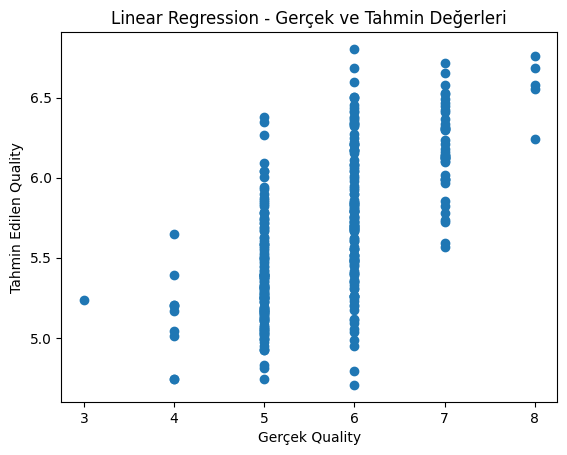

In [23]:
plt.scatter(y_test, y_pred_linear)

plt.xlabel("Gerçek Quality")
plt.ylabel("Tahmin Edilen Quality")
plt.title("Linear Regression - Gerçek ve Tahmin Değerleri")

plt.show()

## **Polynomial Regression**

Soru: Şarabın alkol oranı (alcohol) ile kalite (quality) puanı arasında doğrusal olmayan bir ilişki var mı? 1., 2., 3. ve 4. derece Polynomial Regression modellerinden hangisi daha iyi performans göstermektedir

In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

X = df[["alcohol"]]
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

sonuclar = []

for degree in [1, 2, 3, 4]:

    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    sonuclar.append([degree, mae, mse, rmse, r2])

sonuc_df = pd.DataFrame(
    sonuclar,
    columns=["Degree", "MAE", "MSE", "RMSE", "R²"]
)

display(sonuc_df)

,Degree,MAE,MSE,RMSE,R²
0,1,0.574966,0.499528,0.706773,0.235618
1,2,0.570330,0.502182,0.708648,0.231557
2,3,0.572039,0.497607,0.705413,0.238557
3,4,0.580904,0.510566,0.714539,0.218727


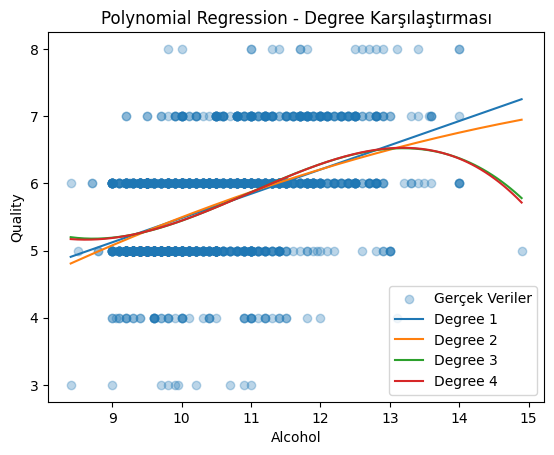

In [30]:
X_grid = pd.DataFrame({
    "alcohol": np.linspace(
        X["alcohol"].min(),
        X["alcohol"].max(),
        200
    )
})

plt.scatter(X["alcohol"], y, alpha=0.3, label="Gerçek Veriler")

for degree in [1, 2, 3, 4]:

    poly = PolynomialFeatures(degree=degree)

    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    X_grid_poly = poly.transform(X_grid)
    y_grid_pred = model.predict(X_grid_poly)

    plt.plot(X_grid["alcohol"], y_grid_pred, label=f"Degree {degree}")

plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Polynomial Regression - Degree Karşılaştırması")
plt.legend()
plt.show()

### **Logistic Regression**

Soru: Şarabın fizikokimyasal özellikleri kullanılarak şarabın iyi kalite (quality ≥ 6) veya düşük kalite (quality < 6) olduğu tahmin edilebilir mi?

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Hedef değişkeni oluşturma
df["iyi_sarap"] = (df["quality"] >= 6).astype(int)

# Bağımsız ve bağımlı değişkenler
X = df.drop(["quality", "iyi_sarap"], axis=1)
y = df["iyi_sarap"]

# Eğitim ve test verisi
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Ölçeklendirme + Logistic Regression
model_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Modeli eğitme
model_logistic.fit(X_train, y_train)

# Tahmin
y_pred_logistic = model_logistic.predict(X_test)

# Sonuçlar
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Accuracy: 0.740625
Precision: 0.7682926829268293
Recall: 0.7368421052631579
F1 Score: 0.7522388059701492

Confusion Matrix:
[[111  38]
 [ 45 126]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.74      0.73       149
           1       0.77      0.74      0.75       171

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320



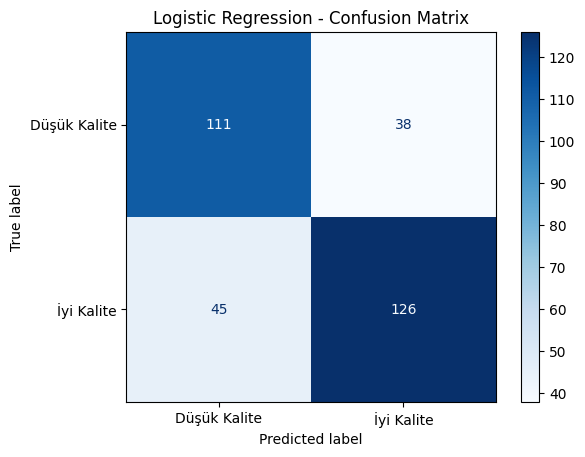

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["Düşük Kalite", "İyi Kalite"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()